## Machine Learning & AI

![Colegio Bourbaki](./Images/Bourbaki.png)

### Modelos Multimodales de Texto e Imágenes

### VLA (Vision-Language-Action)

Un modelo VLA (Vision-Language-Action) es un tipo de modelo de inteligencia artificial diseñado para controlar, por ejemplo, robots usando visión y lenguaje. En general es un codificacdor de vision, uno de texto, los cuales van a aprender una politica de accion.

El modelo recibe tres tipos de información:

Visión: Imágenes del entorno captadas por cámaras del robot. Esto representa lo que el robot está viendo.

Lenguaje: na instrucción en lenguaje natural. El modelo debe entender la tarea.

Acción: El movimiento que el robot debe ejecutar.

En nuestro dataset: action

Esto suele ser un vector que controla:

posición del brazo - orientación - apertura de la pinza

Ejemplo: [dx, dy, dz, gripper]

El modelo aprende una función: (visión + lenguaje) → acción

Es decir: imagen del tablero + instrucción → movimiento del robot


Vamos a implementar un pipeline completo de aprendizaje por imitación.

El flujo es:

Dataset
        ↓
Modelo VLA (TinyVLA)
        ↓
Entrenamiento
        ↓
Visualización y análisis

Vamos a usar el dataset: exidekat/chessbot-lerobot de HG. Este dataset contiene demostraciones de un robot moviendo piezas de ajedrez.

Cada ejemplo del dataset contiene:

observation.images.global   → cámara general
observation.images.gripper  → cámara en la pinza
observation.state           → estado del robot
action                      → acción ejecutada
task                        → instrucción
episode_index               → episodio de demostración
frame_index                 → frame dentro del episodio

Un episodio es una secuencia completa de acciones.

Por ejemplo:

episodio = mover un caballo
frame 1 → robot ve tablero
frame 2 → robot mueve brazo
frame 3 → robot agarra pieza
frame 4 → robot la coloca

En aprendizaje robótico, un episodio es una trayectoria completa.

Ejemplo:

episodio 12
frame 0
frame 1
frame 2
...
frame 150

Cada frame contiene: imagen + estado + acción

El modelo aprende a imitar estas trayectorias. TinyVLA es una arquitectura simplificada para VLA.

Componentes principales:

Encoder visual: Usa ResNet18 para procesar imágenes.

imagen → embedding visual

Encoder de lenguaje: Convierte la instrucción en un vector.

texto → tokens → embedding

Fusión multimodal: Combina visión y lenguaje: embedding_visual + embedding_texto

Head de acciones: Predice la acción del robot.

embedding → acción

Durante el entrenamiento el modelo ve:

imagen - instrucción

y debe predecir:

acción del robot

En qué áreas se usa VLA

Este tipo de modelos se usa en:

robots domésticos

manipulación industrial

robots de cocina

robots de logística

investigación en embodied AI

Ejemplos famosos:

* Google RT-2

* PaLM-E

* OpenVLA

---

### Librerias

In [31]:
import os, sys
from dataclasses import dataclass
from typing import Any, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
import ipywidgets as widgets


from torchvision.models import resnet18

from lerobot.datasets.lerobot_dataset import LeRobotDataset  # <-- full download/cached

### Configs

In [2]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.cuda.empty_cache()
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False

In [3]:
print("__Python VERSION:", sys.version)
print("__pyTorch VERSION:", torch.__version__)
print("__CUDNN VERSION:", torch.backends.cudnn.version())
print("__Number CUDA Devices:", torch.cuda.device_count())
print("__Devices")
print("Active CUDA Device: GPU", torch.cuda.current_device())
print("Available devices ", torch.cuda.device_count())
print("Current cuda device ", torch.cuda.current_device())


__Python VERSION: 3.12.11 (main, Sep  5 2025, 19:35:43) [GCC 13.3.0]
__pyTorch VERSION: 2.9.1+cu130
__CUDNN VERSION: 91300
__Number CUDA Devices: 1
__Devices
Active CUDA Device: GPU 0
Available devices  1
Current cuda device  0


In [4]:
# Config Class
@dataclass
class Cfg:
    repo_id: str = "exidekat/chessbot-lerobot"

    batch_size: int = 8
    lr: float = 1e-4
    steps: int = 200
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 0

    # Simple tokenizer (placeholder)
    max_text_len: int = 64
    vocab_size: int = 8000
    pad_id: int = 0

    # Try common keys for images/text; fallback logic handles differences
    preferred_image_keys = (
        "observation.image",
        "observation.images.global",
        "observation.images.gripper",
        "observation.images.laptop",
        "observation.images.phone",
        "image",
        "images",
    )
    preferred_text_keys = (
        "instruction",
        "task",
        "text",
        "language",
        "observation.language",
        "observation.language.text",
    )



In [5]:
def set_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

### Funciones de ayuda

In [6]:
# ----------------------------
# Helpers: pick fields robustly
# ----------------------------
def pick_action(sample: Dict[str, Any]) -> torch.Tensor:
    if "action" not in sample:
        raise KeyError(f"No 'action' in sample. Keys: {list(sample.keys())[:50]}")
    return sample["action"]


def pick_image(sample: Dict[str, Any], preferred_keys) -> torch.Tensor:
    for k in preferred_keys:
        if k in sample and torch.is_tensor(sample[k]):
            return sample[k]

    # fallback: first tensor that looks like image (C,H,W) or (T,C,H,W)
    for _, v in sample.items():
        if torch.is_tensor(v) and v.ndim in (3, 4):
            return v

    raise KeyError(f"No image tensor found. Keys: {list(sample.keys())[:50]}")


def pick_text(sample: Dict[str, Any], preferred_keys) -> Optional[Any]:
    for k in preferred_keys:
        if k in sample:
            return sample[k]
    return None


def simple_char_tokenize(
    text: str, vocab_size: int, max_len: int, pad_id: int
) -> torch.Tensor:
    # Tiny stand-in tokenizer: hash characters to ids
    if not isinstance(text, str):
        text = str(text)
    ids = [(ord(c) % (vocab_size - 2)) + 2 for c in text[:max_len]]
    ids += [pad_id] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


def collate_fn(batch, cfg: Cfg):
    images, actions, tokens = [], [], []

    for sample in batch:
        img = pick_image(sample, cfg.preferred_image_keys)
        act = pick_action(sample).float().reshape(-1)

        # If video/time dimension present (T,C,H,W), take last frame
        if img.ndim == 4:
            img = img[-1]
        img = img.float()
        if img.max() > 1.5:  # likely 0..255
            img = img / 255.0

        txt = pick_text(sample, cfg.preferred_text_keys)
        if txt is None:
            tok = torch.full((cfg.max_text_len,), cfg.pad_id, dtype=torch.long)
        elif torch.is_tensor(txt) and txt.dtype in (torch.int32, torch.int64):
            tok = txt.reshape(-1)[: cfg.max_text_len].to(torch.long)
            if tok.numel() < cfg.max_text_len:
                tok = F.pad(tok, (0, cfg.max_text_len - tok.numel()), value=cfg.pad_id)
        else:
            tok = simple_char_tokenize(
                str(txt), cfg.vocab_size, cfg.max_text_len, cfg.pad_id
            )

        images.append(img)
        actions.append(act)
        tokens.append(tok)

    return {
        "image": torch.stack(images, dim=0),  # (B,C,H,W)
        "action": torch.stack(actions, dim=0),  # (B,A)
        "tokens": torch.stack(tokens, dim=0),  # (B,T)
    }

### Modelo VLA

In [7]:
# ----------------------------
# Tiny VLA model (vision + text)
# ----------------------------
class TinyVLA(nn.Module):
    def __init__(
        self, action_dim: int, vocab_size: int, max_len: int, d_model: int = 128
    ):
        super().__init__()

        # Vision encoder
        backbone = resnet18(weights=None)
        self.vision = nn.Sequential(*list(backbone.children())[:-1])  # (B,512,1,1)
        self.vis_proj = nn.Linear(512, d_model)

        # Text encoder
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, batch_first=True
        )
        self.text_enc = nn.TransformerEncoder(enc_layer, num_layers=2)

        # Action head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Linear(d_model, action_dim),
        )

    def forward(self, image, tokens):
        B, T = tokens.shape

        v = self.vision(image).flatten(1)  # (B,512)
        v = self.vis_proj(v)  # (B,d)

        pos = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, T)
        x = self.tok_emb(tokens) + self.pos_emb(pos)  # (B,T,d)
        x = self.text_enc(x)  # (B,T,d)
        t = x.mean(dim=1)  # (B,d)

        z = torch.cat([v, t], dim=-1)
        return self.head(z)  # (B,action_dim)

In [8]:
cfg = Cfg()
set_seed(cfg.seed)

In [9]:
ds = LeRobotDataset(
        "exidekat/chessbot-lerobot",
        revision="main",
        video_backend="pyav",
        download_videos=True,
)

In [10]:
first = ds[0]
action_dim = int(pick_action(first).reshape(-1).numel())
print("Loaded:", cfg.repo_id)
print("Example keys:", list(first.keys())[:30])
print("Action dim:", action_dim)

Loaded: exidekat/chessbot-lerobot
Example keys: ['observation.images.global', 'observation.images.gripper', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task']
Action dim: 6


/home/pdconte/.local/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


In [11]:
sample = ds[0]
# check available keys
print(sample.keys())

dict_keys(['observation.images.global', 'observation.images.gripper', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


Vamos a chequear "que ve el robot":

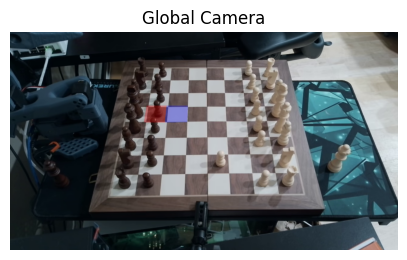

In [12]:
img = sample["observation.images.global"]

plt.figure(figsize=(5, 5))
plt.imshow(img.permute(1, 2, 0))
plt.title("Global Camera")
plt.axis("off")
plt.show()

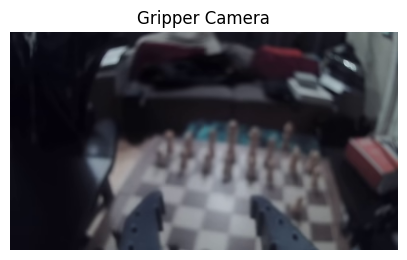

In [13]:
img = sample["observation.images.gripper"]

plt.figure(figsize=(5, 5))
plt.imshow(img.permute(1, 2, 0))
plt.title("Gripper Camera")
plt.axis("off")
plt.show()

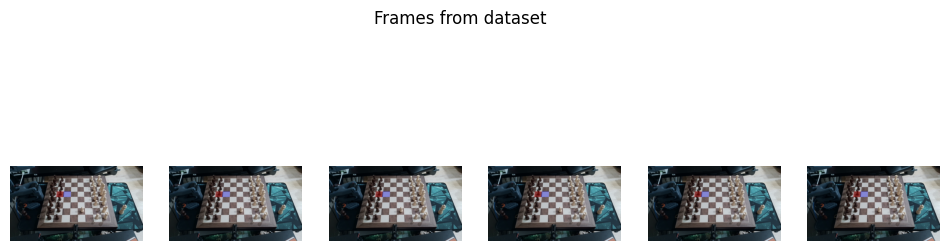

In [14]:
plt.figure(figsize=(12, 4))

for i in range(6):
    sample = ds[i]
    img = sample["observation.images.global"]

    plt.subplot(1, 6, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")

plt.suptitle("Frames from dataset")
plt.show()

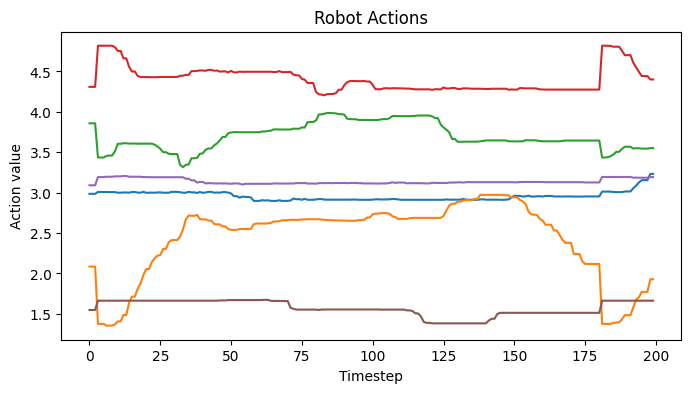

In [15]:
actions = np.array([ds[i]["action"] for i in range(200)])

plt.figure(figsize=(8, 4))
plt.plot(actions)
plt.title("Robot Actions")
plt.xlabel("Timestep")
plt.ylabel("Action value")
plt.show()

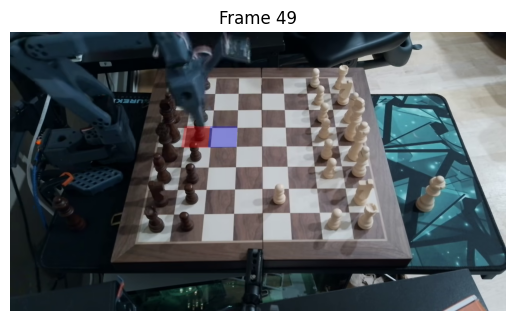

In [16]:
for i in range(50):
    sample = ds[i]
    img = sample["observation.images.global"]

    clear_output(wait=True)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Frame {i}")
    plt.show()

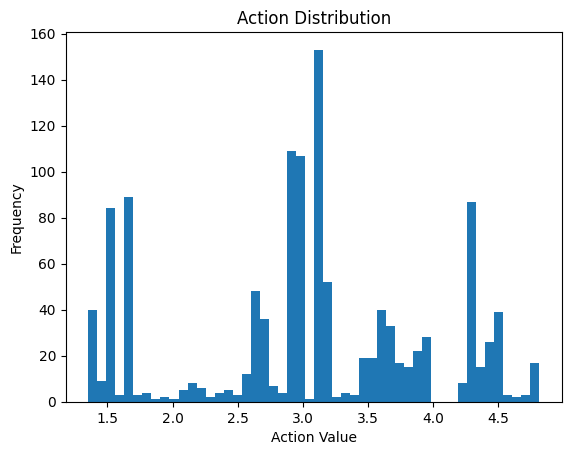

In [17]:
plt.hist(actions.flatten(), bins=50)
plt.title("Action Distribution")
plt.xlabel("Action Value")
plt.ylabel("Frequency")
plt.show()

Cargamos los datos

In [18]:
loader = DataLoader(
    ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    # num_workers=cfg.num_workers,
    drop_last=True,
    pin_memory=cfg.device.startswith("cuda"),
    collate_fn=lambda b: collate_fn(b, cfg),
)

Definimos el modelo

In [19]:
model = TinyVLA(action_dim, cfg.vocab_size, cfg.max_text_len).to(cfg.device)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

In [20]:
it = iter(loader)
model.train()

TinyVLA(
  (vision): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


Entrenamos:

In [21]:
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
loss_history = []
for step in range(1, cfg.steps + 1):
    try:
        batch = next(it)
    except StopIteration:
        it = iter(loader)
        batch = next(it)

    image = batch["image"].to(cfg.device)
    action = batch["action"].to(cfg.device)
    tokens = batch["tokens"].to(cfg.device)

    # optional: shrink images
    image = F.interpolate(image, size=(128, 128), mode="bilinear", align_corners=False)

   
    pred = model(image, tokens)
    loss = F.mse_loss(pred, action)

    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    #loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    #opt.step()
    loss_history.append(loss.item())
    scaler.step(opt)
    scaler.update()    

    if step % 50 == 0:
        print(f"step {step:5d} | loss {loss.item():.6f}")

step    50 | loss 1.162410
step   100 | loss 0.036663
step   150 | loss 0.036733
step   200 | loss 0.023561


In [22]:
os.makedirs("checkpoints", exist_ok=True)
out = "checkpoints/tinyvla_chessbot_full.pt"
torch.save({"model": model.state_dict(), "cfg": cfg.__dict__}, out)
print("Saved:", out)

Saved: checkpoints/tinyvla_chessbot_full.pt


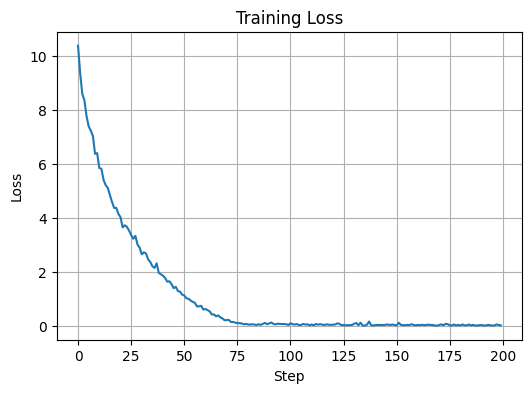

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Vamos a hacer un dashboard para ver al robot en accion:

In [42]:
# --------- helpers ----------
def _to_numpy_image(x):
    """Accepts torch.Tensor or np.ndarray in (C,H,W) or (H,W,C). Returns (H,W,C) uint8-ish."""
    if x is None:
        return None
    if torch.is_tensor(x):
        x = x.detach().cpu()
        if x.ndim == 4:   # (T,C,H,W) -> last frame
            x = x[-1]
        if x.ndim == 3 and x.shape[0] in (1, 3, 4):  # (C,H,W)
            x = x.permute(1, 2, 0)
        x = x.float()
        if x.max() <= 1.5:
            x = x * 255.0
        x = x.clamp(0, 255).to(torch.uint8).numpy()
        return x
    else:
        x = np.asarray(x)
        if x.ndim == 3 and x.shape[0] in (1, 3, 4):  # (C,H,W)
            x = np.transpose(x, (1, 2, 0))
        if x.dtype != np.uint8:
            if x.max() <= 1.5:
                x = (x * 255.0).clip(0, 255).astype(np.uint8)
            else:
                x = x.clip(0, 255).astype(np.uint8)
        return x

def _pick_first(sample, keys):
    for k in keys:
        if k in sample:
            return k, sample[k]
    return None, None

def _find_any_image_keys(sample):
    # Prefer common LeRobot keys; fall back to scanning
    preferred = [
        "observation.images.global",
        "observation.images.gripper",
        "observation.image",
        "image",
        "images",
    ]
    found = [k for k in preferred if k in sample]
    if found:
        return found
    # fallback: any tensor that looks like image
    img_keys = []
    for k, v in sample.items():
        if torch.is_tensor(v) and v.ndim in (3, 4):
            img_keys.append(k)
    return img_keys

def _get_text(sample):
    # common places for instruction/task text
    text_keys = [
        "instruction", "task", "text", "language",
        "observation.language", "observation.language.text"
    ]
    k, v = _pick_first(sample, text_keys)
    if v is None:
        return None, None
    if torch.is_tensor(v):
        # if it's token ids, just print shape
        return k, f"<tensor tokens shape={tuple(v.shape)} dtype={v.dtype}>"
    return k, str(v)

def _safe_action(sample):
    if "action" not in sample:
        return None
    a = sample["action"]
    if torch.is_tensor(a):
        a = a.detach().cpu().float().reshape(-1).numpy()
    else:
        a = np.asarray(a, dtype=np.float32).reshape(-1)
    return a


def task_to_tokens(task: str, vocab_size=8000, max_len=64, pad_id=0):
    if not isinstance(task, str):
        task = str(task)
    ids = [(ord(c) % (vocab_size - 2)) + 2 for c in task[:max_len]]
    ids += [pad_id] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


@torch.no_grad()
def _predict_action(model, device, image_tensor, tokens_tensor=None):
    if model is None:
        return None
    model.eval()
    image_tensor = image_tensor.to(device)
    if tokens_tensor is None:
        # try calling as vision-only model
        pred = model(image_tensor)
    else:
        pred = model(image_tensor, tokens_tensor.to(device))
    if torch.is_tensor(pred):
        pred = pred.detach().cpu().float().reshape(-1).numpy()
    return pred

In [43]:
def lerobot_dashboard(ds, model=None, device=None, max_index=5000):
    """
    ds: LeRobotDataset (or compatible) already created in your notebook.
    model: optional torch.nn.Module for predicted actions
    device: 'cuda' or 'cpu' (auto if None)
    max_index: slider upper bound (keep modest to avoid slow metadata ops)
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # UI controls
    n = len(ds)
    upper = min(n - 1, max_index)
    idx = widgets.IntSlider(
        value=0, min=0, max=upper, step=1, description="idx", continuous_update=False
    )
    show_keys = widgets.Checkbox(value=False, description="show keys")
    downscale = widgets.IntSlider(
        value=0,
        min=0,
        max=512,
        step=32,
        description="downscale (px)",
        continuous_update=False,
    )
    btn = widgets.Button(description="Render", button_style="primary")
    out = widgets.Output()

    def render(_=None):
        with out:
            clear_output(wait=True)
            sample = ds[int(idx.value)]

            if show_keys.value:
                print("keys:", list(sample.keys()))

            # images
            img_keys = _find_any_image_keys(sample)
            global_k = (
                "observation.images.global"
                if "observation.images.global" in sample
                else (img_keys[0] if img_keys else None)
            )
            gripper_k = (
                "observation.images.gripper"
                if "observation.images.gripper" in sample
                else (img_keys[1] if len(img_keys) > 1 else None)
            )

            global_img = _to_numpy_image(sample.get(global_k)) if global_k else None
            gripper_img = _to_numpy_image(sample.get(gripper_k)) if gripper_k else None

            # optional downscale for memory/speed in notebook display
            def _maybe_downscale(img):
                if img is None or downscale.value <= 0:
                    return img
                # keep aspect ratio; simple nearest-neighbor via slicing is fine for viz
                h, w = img.shape[:2]
                target = downscale.value
                if max(h, w) <= target:
                    return img
                scale = target / max(h, w)
                nh, nw = int(h * scale), int(w * scale)
                # use numpy indexing (fast & low dependency)
                ys = (np.linspace(0, h - 1, nh)).astype(int)
                xs = (np.linspace(0, w - 1, nw)).astype(int)
                return img[ys][:, xs]

            global_img = _maybe_downscale(global_img)
            gripper_img = _maybe_downscale(gripper_img)

            # text
            text_k, text_v = _get_text(sample)

            # action
            action = _safe_action(sample)

            # predicted action (optional)
            pred = None
            if model is not None and global_k is not None and torch.is_tensor(sample[global_k]):
                img_t = sample[global_k]
                if img_t.ndim == 4:
                    img_t = img_t[-1]
                img_t = img_t.float()
                if img_t.max() > 1.5:
                    img_t = img_t / 255.0
                img_t = img_t.unsqueeze(0)  # (1,C,H,W)

                # NEW: tokenize the task text
                task_text = sample.get("task", "")
                tok = task_to_tokens(task_text, vocab_size=8000, max_len=64, pad_id=0).unsqueeze(0)  # (1,T)

                pred = _predict_action(model, device, img_t, tokens_tensor=tok)

            # layout
            ncols = 2 if (global_img is not None and gripper_img is not None) else 1
            fig = plt.figure(figsize=(10, 4))

            # images row
            ax1 = plt.subplot(1, ncols, 1)
            if global_img is not None:
                ax1.imshow(global_img)
                ax1.set_title(global_k)
                ax1.axis("off")
            else:
                ax1.text(0.5, 0.5, "No image found", ha="center", va="center")
                ax1.axis("off")

            if ncols == 2:
                ax2 = plt.subplot(1, ncols, 2)
                if gripper_img is not None:
                    ax2.imshow(gripper_img)
                    ax2.set_title(gripper_k)
                    ax2.axis("off")
                else:
                    ax2.text(
                        0.5, 0.5, "No second image found", ha="center", va="center"
                    )
                    ax2.axis("off")

            plt.show()
            plt.close(fig)

            # text + actions
            if text_v is not None:
                print(f"{text_k}: {text_v}")

            if action is None:
                print("No 'action' found in sample.")
                return

            fig2 = plt.figure(figsize=(10, 3))
            ax = plt.gca()
            ax.bar(np.arange(len(action)), action)
            ax.set_title("Action (ground truth)")
            ax.set_xlabel("action dim")
            ax.set_ylabel("value")
            plt.show()
            plt.close(fig2)

            if pred is not None and pred.shape == action.shape:
                fig3 = plt.figure(figsize=(10, 3))
                ax = plt.gca()
                ax.plot(action, label="GT")
                ax.plot(pred, label="Pred")
                ax.set_title("Action: GT vs Pred")
                ax.legend()
                plt.show()
                plt.close(fig3)

    btn.on_click(render)

    display(
        widgets.VBox(
            [widgets.HBox([idx, btn]), widgets.HBox([show_keys, downscale]), out]
        )
    )
    render()

In [44]:
lerobot_dashboard(ds)

In [ ]:
lerobot_dashboard(ds, model=model, device="cuda")

Vamos a verlo en un video:

In [50]:
@torch.no_grad()
def play_episode(ds, episode_id, model=None, device=None, n_frames=200, sleep=0.0):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if model is not None:
        model.eval().to(device)

    # find indices belonging to this episode
    # FAST lookup
    idxs = np.where(ds.hf_dataset["episode_index"] == episode_id)[0][:n_frames]
    idxs = idxs[:n_frames]
    if not idxs:
        print("No frames found for episode:", episode_id)
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    display(fig)

    for k, i in enumerate(idxs):
        s = ds[i]
        img = s["observation.images.global"]
        if img.ndim == 4:
            img = img[-1]
        img_np = img.permute(1, 2, 0).detach().cpu().float()
        if img_np.max() <= 1.5:
            img_np = (img_np * 255).clamp(0, 255)
        img_np = img_np.to(torch.uint8).numpy()

        gt = s["action"].detach().cpu().float().reshape(-1).numpy()
        task = s.get("task", "")

        pred = None
        if model is not None:
            im_t = img.detach().float()
            if im_t.max() > 1.5:
                im_t = im_t / 255.0
            im_t = im_t.unsqueeze(0).to(device)  # (1,C,H,W)
            tok = task_to_tokens(task).unsqueeze(0).to(device)  # (1,T)
            pred = model(im_t, tok).detach().cpu().float().reshape(-1).numpy()

        ax.clear()
        ax.imshow(img_np)
        ax.axis("off")

        title = f"ep={episode_id}  frame={k}  idx={i}\n"
        if task:
            title += f"task: {task}\n"
        title += f"GT:   {np.array2string(gt, precision=2, suppress_small=True)}"
        if pred is not None:
            title += (
                f"\nPred: {np.array2string(pred, precision=2, suppress_small=True)}"
            )
        ax.set_title(title, fontsize=9)

        clear_output(wait=True)
        display(fig)

        if sleep > 0:
            import time

            time.sleep(sleep)

    plt.close(fig)

In [51]:
# grab a few episode ids
eps = [int(ds[i]["episode_index"]) for i in range(0, min(len(ds), 500), 10)]
print("some episode ids:", sorted(set(eps))[:20])

some episode ids: [0, 1, 2]


In [52]:
play_episode(ds, episode_id=eps[0], model=None, n_frames=150)

ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

In [53]:
play_episode(ds, episode_id=eps[0], model=model, device="cuda", n_frames=150)

ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.


---

## Ejercicio:

Clonar el repo BridgeVLA: https://github.com/BridgeVLA/BridgeVLA y correr un Fine Tuning sobre el modelo

### BridgeVLA

![Colegio Bourbaki](./Images/vla.png)

BridgeVLA es un modelo **Vision-Language-Action** para manipulación 3D que hace un truco clave:

- **Entrada 3D** (nube de puntos) → se **proyecta** a múltiples vistas 2D (imágenes).
- **Salida de acción** → se representa primero como **heatmaps 2D** (por ejemplo, para traslación).
- Esto “alinea” tanto el *input* como el *output* en el **mismo espacio 2D**, lo que facilita:
  - pre-entrenamiento escalable con datasets 2D (detección),
  - y fine-tuning eficiente en tareas de manipulación.

**Repositorio:** https://github.com/BridgeVLA/BridgeVLA  
**Paper (arXiv):** https://arxiv.org/abs/2506.07961  

En el repo, el fine-tuning se soporta (al menos) para:
- RLBench
- COLOSSEUM
- GemBench


1. **Estructura del repo** y componentes que se fine-tunean  
2. **Requisitos** de entorno (incluyendo el backbone *PaLI-Gemma* que es gated)  
3. **Datos RLBench**: de demos a *replay buffer*  
4. **Configuración** (`rlbench_config.yaml`) y knobs importantes  
5. **Lanzar el fine-tuning** (`torchrun train.py ...`) y variantes típicas (freeze / full)  
6. **Evaluación** y troubleshooting frecuente (CoppeliaSim, OpenCV headless, Xvfb)

![Contacto](./Images/Contacto.png)

![Lenguaje Matemático](./Images/Matematicas.png)